In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import itertools
import time
from joblib import Parallel, delayed

In [2]:
import yfinance as yf
import pandas as pd

def fetch_turtle_universe():
    print("🌍 Initialisation du téléchargement de l'univers Turtle...")
    
    # 1. Sélection des Tickers (Le panier macro-économique)
    turtle_assets = {
        'Commodities': ['GC=F', 'CL=F', 'SI=F', 'HG=F', 'ZC=F'], # Or, Pétrole Brut, Argent, Cuivre, Maïs
        'Forex': ['EURUSD=X', 'USDJPY=X', 'GBPUSD=X'],           # Euro, Yen, Livre Sterling                                # Bons du Trésor US 20+ ans et 7-10 ans
        #'Crypto': ['BTC-USD', 'ETH-USD'], 
        #'Indice': ['TQQQ']                        # Bitcoin, Ethereum
    }
    
    # Aplatissement du dictionnaire en une seule liste de tickers
    tickers = [ticker for category in turtle_assets.values() for ticker in category]
    
    # 2. Téléchargement depuis Yahoo Finance (Historique long)
    print(f"📥 Téléchargement de {len(tickers)} actifs depuis 1900...")
    raw_data = yf.download(tickers, start="1900-01-01", interval='1d', progress=True)
    
    # 3. Transformation des données (Wide to Long Format)
    print("⚙️ Restructuration du DataFrame pour l'algorithme...")
    
    # yfinance renvoie un MultiIndex. On "empile" (stack) le niveau des Tickers pour en faire une colonne
    # Le level=1 correspond généralement aux Tickers dans les récentes versions de yfinance
    df = raw_data.stack(level=1, future_stack=True).reset_index()
    
    # 4. Renommage strict pour correspondre à ton algorithme
    # (Attention à la casse des lettres, Pandas ne pardonne pas)
    df = df.rename(columns={
        'Date': 'date',
        'Ticker': 'symbol', # Le nom généré par stack()
        'High': 'high',
        'Low': 'low',
        'Close': 'close',
        'Open': 'open',
        'Volume': 'volume'
    })
    
    # 5. Nettoyage et tri final
    # On s'assure que la date est au bon format
    df['date'] = pd.to_datetime(df['date']).dt.tz_localize(None) 
    
    # Tri par actif puis par date chronologique
    df = df.sort_values(by=['symbol', 'date']).reset_index(drop=True)
    
    # Suppression des jours sans cotation (ex: jours fériés)
    df = df.dropna(subset=['close', 'high', 'low'])
    
    print(f"✅ Terminé ! DataFrame généré avec {len(df)} lignes.")
    return df

# ==========================================
# 🚀 EXÉCUTION
# ==========================================
df = fetch_turtle_universe()

# Vérification visuelle
print("\nAperçu des données prêtes pour le backtest :")
display(df.head())
print("\nListe des actifs disponibles dans df :", df['symbol'].unique())

🌍 Initialisation du téléchargement de l'univers Turtle...
📥 Téléchargement de 8 actifs depuis 1900...


[*********************100%***********************]  8 of 8 completed

⚙️ Restructuration du DataFrame pour l'algorithme...
✅ Terminé ! DataFrame généré avec 51294 lignes.

Aperçu des données prêtes pour le backtest :


Price,date,symbol,close,high,low,open,volume
981,2000-08-23,CL=F,32.049999,32.799999,31.950001,31.950001,79385.0
982,2000-08-24,CL=F,31.629999,32.240002,31.400000,31.900000,72978.0
983,2000-08-25,CL=F,32.049999,32.099998,31.320000,31.700001,44601.0
984,2000-08-28,CL=F,32.869999,32.919998,31.860001,32.040001,46770.0
985,2000-08-29,CL=F,32.720001,33.029999,32.560001,32.820000,49131.0



Liste des actifs disponibles dans df : ['CL=F' 'EURUSD=X' 'GBPUSD=X' 'GC=F' 'HG=F' 'SI=F' 'USDJPY=X' 'ZC=F']


In [3]:
import numpy as np
import pandas as pd

def generate_turtle_signals(
    df,
    entry_window=55,
    ma_short=50,
    ma_long=200,
    atr_window=20,
    risk_per_trade=0.01  
):
    """
    Génère les signaux Turtle (Long ET Short) avec Sortie Adaptative (Dual MA).
    Spécialement optimisé pour capter les tendances macro (Forex, Commodities).
    """
    required_cols = ['symbol', 'date', 'high', 'low', 'close']
    if not all(col in df.columns for col in required_cols):
        raise ValueError(f"❌ Colonnes manquantes. Requis : {required_cols}")

    data = df[required_cols].copy()
    data = data.sort_values(['symbol', 'date'])

    # --- Étape A : Calcul de l'ATR (N) ---
    data['Prev_Close'] = data.groupby('symbol')['close'].shift(1)
    high_low = data['high'] - data['low']
    high_close = (data['high'] - data['Prev_Close']).abs()
    low_close = (data['low'] - data['Prev_Close']).abs()
    
    data['TR'] = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    data['N'] = data.groupby('symbol')['TR'].transform(lambda x: x.ewm(span=atr_window, adjust=False).mean())

    # --- Étape B : Canaux de Donchian (Breakouts Hauts et Bas) ---
    data['Entry_Max'] = data.groupby('symbol')['high'].transform(lambda x: x.rolling(entry_window).max().shift(1))
    data['Entry_Min'] = data.groupby('symbol')['low'].transform(lambda x: x.rolling(entry_window).min().shift(1))

    # --- Étape C : Moyennes Mobiles & Lignes de Sortie Dynamiques ---
    data['MA_Short'] = data.groupby('symbol')['close'].transform(lambda x: x.rolling(ma_short).mean().shift(1))
    data['MA_Long'] = data.groupby('symbol')['close'].transform(lambda x: x.rolling(ma_long).mean().shift(1))

    # Ligne de sortie pour les ACHATS (Long)
    data['Exit_Threshold_Long'] = np.where(data['MA_Short'] >= data['MA_Long'], data['MA_Long'], data['MA_Short'])
    
    # Ligne de sortie pour les VENTES (Short) -> Logique inversée
    data['Exit_Threshold_Short'] = np.where(data['MA_Short'] <= data['MA_Long'], data['MA_Long'], data['MA_Short'])

    # --- Étape D : Signaux Logiques ---
    # 📈 LONG (1)
    data['Long_Signal'] = np.where((data['close'] > data['Entry_Max']) & (data['close'] > data['Exit_Threshold_Long']), 1, np.nan)
    data['Long_Signal'] = np.where(data['close'] < data['Exit_Threshold_Long'], 0, data['Long_Signal'])
    data['Long_Signal'] = data.groupby('symbol')['Long_Signal'].ffill().fillna(0)

    # 📉 SHORT (-1)
    data['Short_Signal'] = np.where((data['close'] < data['Entry_Min']) & (data['close'] < data['Exit_Threshold_Short']), -1, np.nan)
    data['Short_Signal'] = np.where(data['close'] > data['Exit_Threshold_Short'], 0, data['Short_Signal'])
    data['Short_Signal'] = data.groupby('symbol')['Short_Signal'].ffill().fillna(0)

    # Combinaison (0 = Cash, 1 = Achat, -1 = Vente)
    data['Signal'] = data['Long_Signal'] + data['Short_Signal']

    # --- Étape E : Position Sizing par l'ATR ---
    data['Pct_Volatility'] = data['N'] / data['close']
    
    # Le poids Target hérite du signe du signal (+ pour achat, - pour vente)
    data['Target_Weight'] = np.where(
        (data['Signal'] != 0) & (data['Pct_Volatility'] > 0), 
        (risk_per_trade / data['Pct_Volatility']) * data['Signal'], 
        0.0
    )

    # --- Étape F : Portfolio Heat (Levier max global) ---
    max_leverage = 2.0
    
    # ⚠️ CRUCIAL : On additionne la valeur ABSOLUE des poids pour calculer l'exposition. 
    # (Sans abs(), une position Long de 50% et Short de -50% donnerait 0% d'exposition, ce qui est faux).
    data['Total_Exposure'] = data.groupby('date')['Target_Weight'].transform(lambda x: x.abs().sum())
    
    data['Target_Weight'] = np.where(
        data['Total_Exposure'] > max_leverage,
        data['Target_Weight'] * (max_leverage / data['Total_Exposure']),
        data['Target_Weight']
    )

    # Rendement Futur
    data['NextReturn'] = data.groupby('symbol')['close'].shift(-1) / data['close'] - 1
    
    return data.dropna(subset=['NextReturn', 'N', 'MA_Long'])

In [4]:
# ==========================================
# 2. MOTEUR DE BACKTEST
# ==========================================
def run_vectorized_backtest(data, transaction_cost=0.002): 
    data['Weight_Change'] = data.groupby('symbol')['Target_Weight'].diff().fillna(data['Target_Weight'])
    data['Cost'] = data['Weight_Change'].abs() * transaction_cost
    data['Strat_Return'] = data['Target_Weight'] * data['NextReturn']
    data['is_trade'] = (data['Weight_Change'].abs() > 0.001).astype(int)
    
    port_returns = data.groupby('date')[['Strat_Return', 'Cost', 'is_trade']].sum()
    port_returns['Net_Return'] = port_returns['Strat_Return'] - port_returns['Cost']
    port_returns['Capital'] = (1 + port_returns['Net_Return']).cumprod()
    
    return port_returns

In [5]:
def run_single_backtest(params, df_source, start_date, end_date):
    # 🛠️ DÉCOMPRESSION DES 5 PARAMÈTRES
    entry_win, ma_s, ma_l, atr_win, risk_pct = params

    default_output = {
        "Entry_Window": entry_win, "MA_Short": ma_s, "MA_Long": ma_l,
        "ATR_Window": atr_win, "Risk_Per_Trade": risk_pct,
        "Total Return": np.nan, "CAGR": np.nan, "Calmar Ratio": np.nan,
        "Max Drawdown": np.nan, "Sharpe Ratio": np.nan, "Error": None
    }

    try:
        df_source = df_source.copy()
        df_source['date'] = pd.to_datetime(df_source['date'])
        
        full_signals = generate_turtle_signals(
            df_source, entry_window=entry_win, ma_short=ma_s, 
            ma_long=ma_l, atr_window=atr_win, risk_per_trade=risk_pct
        )

        mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
        backtest_data = full_signals.loc[mask].copy()

        if backtest_data.empty:
            default_output["Error"] = "No data"
            return default_output

        res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.002)

        final_cap = res_df['Capital'].iloc[-1]
        n_days = (res_df.index[-1] - res_df.index[0]).days
        n_years = n_days / 365.25 if n_days >= 1 else 1.0
        
        cagr = (final_cap ** (1 / n_years)) - 1 if final_cap > 0 else -1.0
        
        rolling_max = res_df['Capital'].cummax()
        max_dd = ((res_df['Capital'] - rolling_max) / rolling_max).min() if rolling_max.iloc[-1] > 0 else -1.0
        
        mean_ret = res_df['Net_Return'].mean()
        std_ret = res_df['Net_Return'].std()
        sharpe = (mean_ret / std_ret) * np.sqrt(252) if std_ret > 0 else 0 
        calmar = abs(cagr / max_dd) if max_dd != 0 else 0 

        output = default_output.copy()
        output.update({
            "Total Return": final_cap - 1, "CAGR": cagr,
            "Calmar Ratio": calmar, "Max Drawdown": max_dd, "Sharpe Ratio": sharpe
        })
        return output

    except Exception as e:
        default_output["Error"] = repr(e) 
        return default_output



In [6]:
def grid_search_execution(df, param_grid, start_date, end_date):
    keys, values = zip(*param_grid.items())
    combinations = [v for v in itertools.product(*values) if v[1] < v[2]]

    print(f"🚀 Lancement de la Grid Search sur {len(combinations)} combinaisons logiques...")
    start_time = time.time()

    results_list = Parallel(n_jobs=-1)(
        delayed(run_single_backtest)(params, df, start_date, end_date) for params in combinations
    )

    end_time = time.time()
    print(f"✅ Terminé en {end_time - start_time:.2f} secondes.")

    results_df = pd.DataFrame(results_list)
    if results_df.empty or 'Error' not in results_df.columns:
        print("⚠️ Attention : Aucun backtest généré.")
        return results_df
    
    # ⚠️ TRI PAR CAGR POUR LA STRATÉGIE AGRESSIVE
    best_strats = results_df[results_df['Error'].isna()].sort_values(by='CAGR', ascending=False)
    return best_strats

In [7]:
def analyze_best_strategy(best_df, df_source, start_date, end_date):
    if best_df.empty:
        print("❌ Aucune stratégie valide trouvée.")
        return None, None
        
    best_params = best_df.sort_values(by='CAGR', ascending=False).iloc[0]
    
    entry_win = int(best_params['Entry_Window'])
    ma_s = int(best_params['MA_Short'])
    ma_l = int(best_params['MA_Long'])
    atr_win = int(best_params['ATR_Window'])
    risk_pct = float(best_params['Risk_Per_Trade'])
    
    print("\n🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE AGRESSIVE ---")
    print(f"Entrée: {entry_win}j | MA_Short: {ma_s}j | MA_Long: {ma_l}j | ATR: {atr_win}j | Risque/Trade: {risk_pct*100:.1f}%")
    
    full_signals = generate_turtle_signals(
        df_source, entry_window=entry_win, ma_short=ma_s, 
        ma_long=ma_l, atr_window=atr_win, risk_per_trade=risk_pct
    )
    
    mask = (full_signals['date'] >= pd.to_datetime(start_date)) & (full_signals['date'] <= pd.to_datetime(end_date))
    backtest_data = full_signals.loc[mask].copy()
    res_df = run_vectorized_backtest(backtest_data, transaction_cost=0.002)
    
    try:
        gspc_data = yf.download('^NDX', start=start_date, end=end_date, interval='1d', progress=False)
        gspc_close = gspc_data['Close']['^NDX'] if isinstance(gspc_data.columns, pd.MultiIndex) else gspc_data['Close']
        gspc_close.index = pd.to_datetime(gspc_close.index).tz_localize(None)
        
        aligned_gspc = pd.DataFrame(index=pd.to_datetime(res_df.index).tz_localize(None))
        aligned_gspc['GSPC_Price'] = gspc_close.reindex(aligned_gspc.index, method='ffill').bfill()
        res_df['GSPC_Capital'] = aligned_gspc['GSPC_Price'] / aligned_gspc['GSPC_Price'].iloc[0]
    except:
        res_df['GSPC_Capital'] = 1.0 

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
    
    ax1.plot(res_df.index, res_df['Capital'], color='royalblue', linewidth=2.5, 
             label=f"Stratégie Agressive (Sharpe: {best_params['Sharpe Ratio']:.1f}, CAGR: {best_params['CAGR']*100:.1f}%, MaxDD: {best_params['Max Drawdown']*100:.1f}%)")
    ax1.plot(res_df.index, res_df['GSPC_Capital'], color='dimgray', linewidth=1.5, linestyle='--', label="S&P 500 (^GSPC)")
    ax1.set_yscale('log')
    ax1.set_title("Évolution du Capital (Compte de 1000$)", fontsize=14, fontweight='bold')
    ax1.grid(True, which="both", ls="--", alpha=0.4)
    ax1.legend(loc='upper left', fontsize=12)
    
    ax2.bar(res_df.index, res_df['is_trade'], color='purple', width=3, alpha=0.5, label='Transactions')
    ax2.set_title("Activité de Trading", fontsize=12)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return res_df, backtest_data

🚀 Lancement de la Grid Search sur 81 combinaisons logiques...


/opt/homebrew/Caskroom/miniforge/base/envs/ml-prod-v2/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


✅ Terminé en 4.07 secondes.


,Entry_Window,MA_Short,MA_Long,ATR_Window,Risk_Per_Trade,Total Return,CAGR,Calmar Ratio,Max Drawdown,Sharpe Ratio,Error
72,100,80,150,20,0.03,-0.526963,-0.034691,0.041750,-0.830929,-0.043028,None
73,100,80,150,20,0.05,-0.536733,-0.035641,0.042864,-0.831494,-0.047180,None
74,100,80,150,20,0.08,-0.548288,-0.036789,0.044245,-0.831494,-0.052084,None
54,100,40,150,20,0.03,-0.557561,-0.037731,0.045547,-0.828403,-0.055968,None
55,100,40,150,20,0.05,-0.566700,-0.038678,0.046657,-0.828977,-0.060100,None



🏆 --- RECALCUL DE LA MEILLEURE STRATÉGIE AGRESSIVE ---
Entrée: 100j | MA_Short: 80j | MA_Long: 150j | ATR: 20j | Risque/Trade: 3.0%


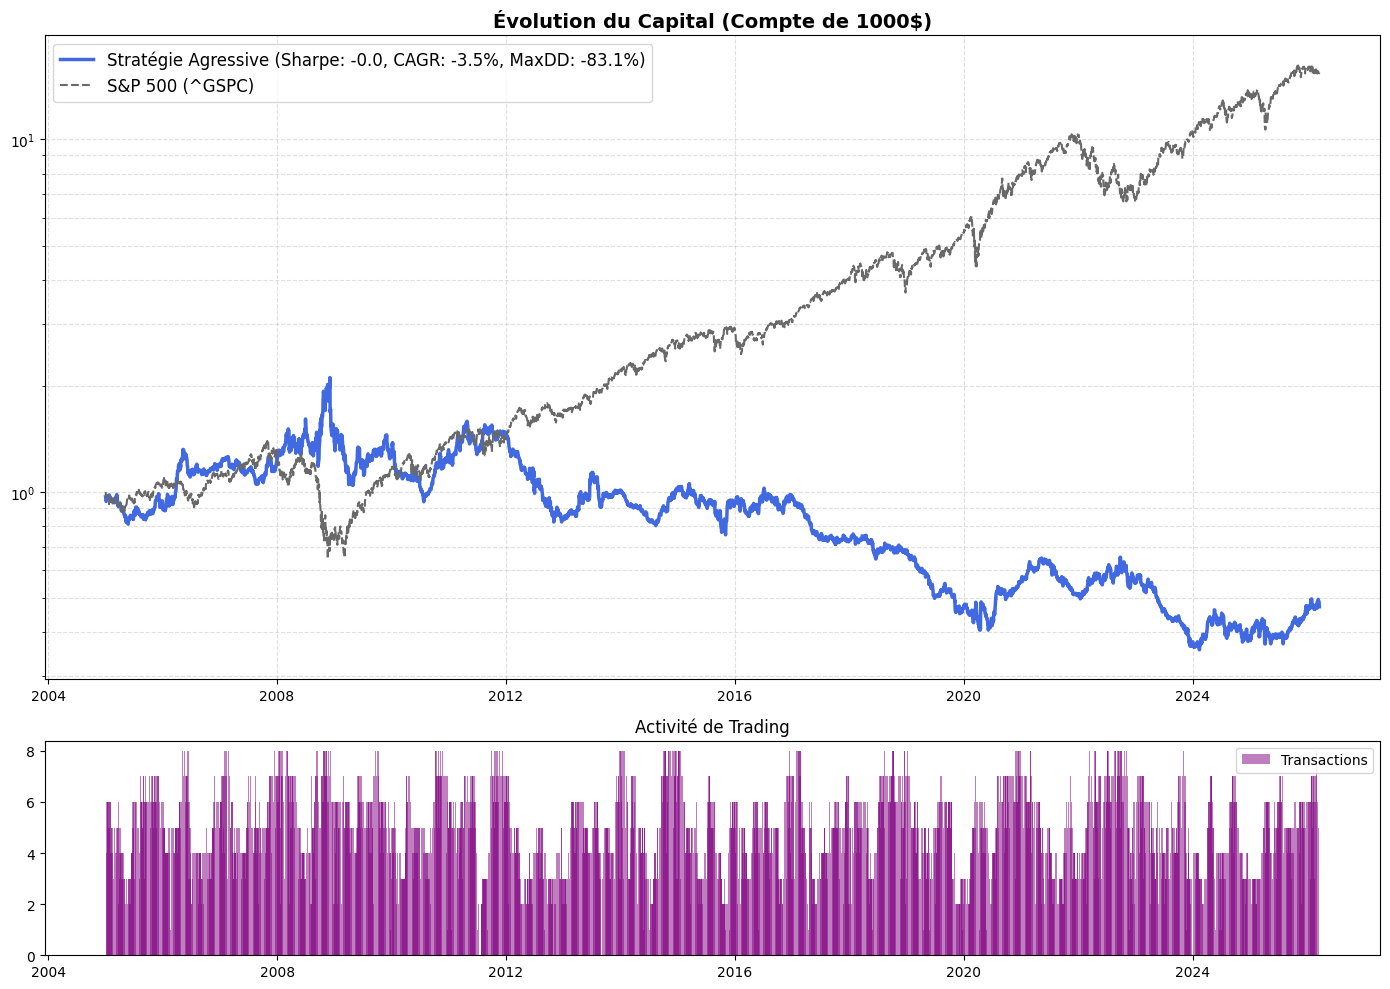

In [12]:
# Grille optimisée pour "Survivre aux Ranges" et "Capter les Tendances Macro"
param_grid = {
    'entry_window': [55, 80, 100],          
    'ma_short': [40, 50, 80],               
    'ma_long': [150, 200, 250],             
    'atr_window': [20],                     
    'risk_per_trade': [0.03, 0.05, 0.08]    # Entre 3% et 8% (Kamikaze contrôlé)
}

best_strategies_df = grid_search_execution(df, param_grid, start_date='2005-01-01', end_date='2026-03-18')

# Affiche le TOP 5 
display(best_strategies_df.head(5))

portfolio_stats, all_trades_history = analyze_best_strategy(best_strategies_df, df, start_date='2005-01-01', end_date='2026-03-18')

In [9]:
all_trades_history[all_trades_history['Signal']!=0].sort_values(by=['date'], ascending=False)

Price,symbol,date,high,low,close,Prev_Close,TR,N,Entry_Max,Entry_Min,...,Short_Signal,Signal,Pct_Volatility,Target_Weight,Total_Exposure,NextReturn,Weight_Change,Cost,Strat_Return,is_trade
7647,CL=F,2026-03-18,100.550003,91.959999,96.320000,96.209999,8.590004,8.417738,119.480003,54.980000,...,0.0,1.0,0.087393,0.092881,12.319496,-0.001869,0.002920,0.000006,-0.000174,1
53553,USDJPY=X,2026-03-18,159.565994,158.567001,158.889008,159.104996,0.998993,1.149038,159.630997,146.216995,...,0.0,1.0,0.007232,1.122448,12.319496,0.005702,0.049661,0.000099,0.006400,1
45902,SI=F,2026-03-18,77.735001,74.800003,77.237999,79.529999,4.729996,5.022039,121.300003,37.205002,...,0.0,1.0,0.065020,0.124841,12.319496,-0.082032,0.001220,0.000002,-0.010241,1
30600,GC=F,2026-03-18,4949.600098,4821.700195,4889.899902,5001.000000,179.299805,109.353686,5586.200195,3310.100098,...,0.0,1.0,0.022363,0.362972,12.319496,-0.059142,-0.022141,0.000044,-0.021467,1
38251,HG=F,2026-03-18,5.734000,5.440000,5.554000,5.726500,0.294000,0.151868,6.508000,4.407500,...,0.0,1.0,0.027344,0.296857,12.319496,-0.021786,-0.031660,0.000063,-0.006467,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55676,ZC=F,2005-01-03,203.500000,203.000000,201.750000,204.750000,1.750000,1.420705,326.500000,191.500000,...,-1.0,-1.0,0.007042,-0.452256,31.399717,-0.003717,-0.452256,0.000905,0.001681,1
32723,HG=F,2005-01-03,1.524000,1.500000,1.523500,1.487000,0.037000,0.035204,1.550000,1.132000,...,0.0,1.0,0.023107,0.137824,31.399717,-0.084345,0.137824,0.000276,-0.011625,1
48025,USDJPY=X,2005-01-03,103.430000,102.349998,102.739998,102.510002,1.080002,0.944368,112.470001,101.900002,...,-1.0,-1.0,0.009192,-0.346476,31.399717,0.015573,-0.346476,0.000693,-0.005396,1
17421,GBPUSD=X,2005-01-03,1.919791,1.900490,1.904617,1.919791,0.019301,0.017182,1.954881,1.771510,...,0.0,1.0,0.009021,0.353028,31.399717,-0.011038,0.353028,0.000706,-0.003897,1
